In [1]:
! pwd

/home/audbhav22/ronit/LWM/lwm


In [2]:
! which python

/home/audbhav22/.conda/envs/lwm_lab/bin/python


In [3]:
import subprocess
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, random_split, TensorDataset
import csv, json, time
from sklearn.metrics import f1_score
from tqdm import tqdm  # Progress bar
import torch.optim as optim
import math




from input_preprocess import tokenizer, create_labels
from lwm_model import lwm
from inference import lwm_inference, create_raw_dataset

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using",device)

Using cuda


In [5]:
# Define scenario names and select one (or more).
scenario_names = np.array([
    "city_0_newyork", "city_1_losangeles", "city_2_chicago", "city_3_houston", 
    "city_4_phoenix", "city_5_philadelphia", "city_6_miami", "city_7_sandiego", 
    "city_8_dallas", "city_9_sanfrancisco", "city_10_austin", "city_11_santaclara", 
    "city_12_fortworth", "city_13_columbus", "city_15_indianapolis", "city_17_seattle", 
    "city_18_denver", "city_19_oklahoma"])
# Select the first scenario (index 0) – adjust as needed.
scenario_idxs = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])[0:18]
selected_scenario_names = scenario_names[scenario_idxs]

snr_db = None
preprocessed_chs = tokenizer(
    selected_scenario_names=selected_scenario_names,
    manual_data=None,
    gen_raw=True,
    snr_db=snr_db
)


Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 5148/5148 [00:00<00:00, 52407.29it/s]



Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 4617/4617 [00:00<00:00, 69603.56it/s]



Basestation 1

UE-BS Channels


...

Generating channels: 100%|██████████| 6068/6068 [00:00<00:00, 47192.11it/s]



Basestation 3

UE-BS Channels


Generating channels: 100%|██████████| 6970/6970 [00:00<00:00, 67587.19it/s]



Basestation 1

UE-BS Channels


Processing items: 100%|██████████| 33664/33664 [00:00<00:00, 43407.10it/s]


In [6]:
lwm_model = lwm.from_pretrained(device=device)

Model loaded successfully from model_weights.pth to cuda


In [7]:
#######SELECT INPUT#####################################

input_types = ['cls_emb', 'channel_emb', 'raw']
selected_input_type = input_types[0] # choose one: 'cls_emb', 'channel_emb', or 'raw'
if selected_input_type in ['cls_emb', 'channel_emb']:
    dataset = lwm_inference(preprocessed_chs, selected_input_type, lwm_model, device)
else:
    dataset = create_raw_dataset(preprocessed_chs, device)
# At this point, `dataset` should be a torch Dataset yielding (data, target) pairs.
# print(type(dataset),'\n',"dataset: (",len(dataset),len(dataset[0]),len(dataset[0][0]),')')


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5148/5148 [00:00<00:00, 225266.84it/s]


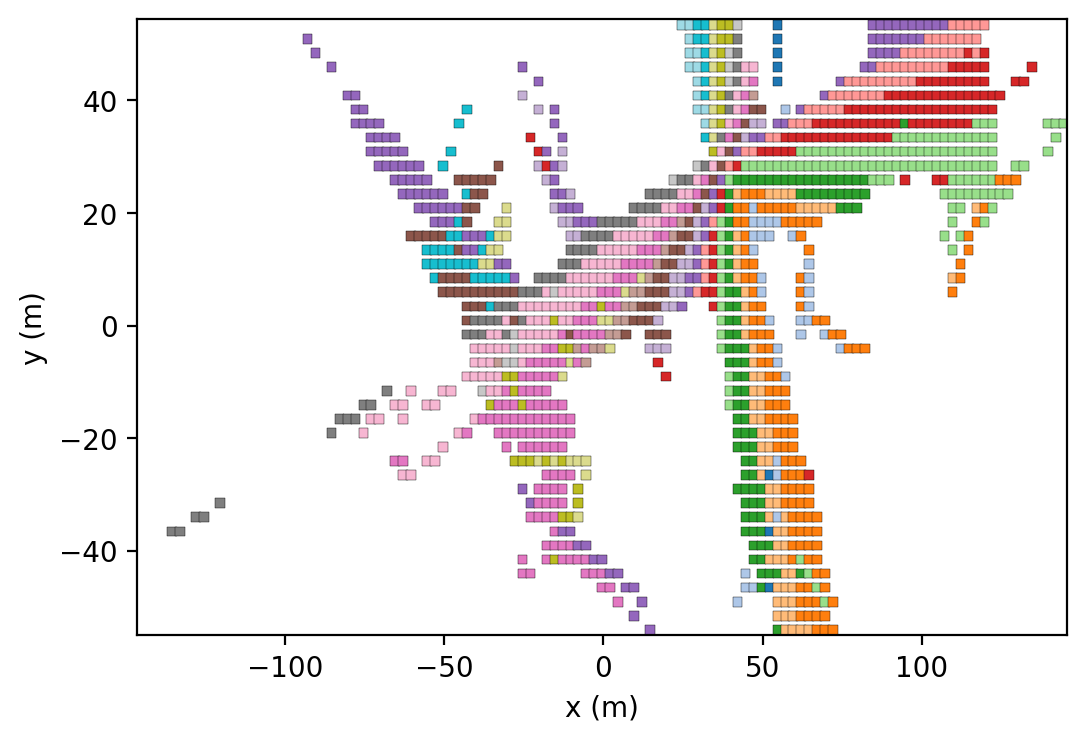


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 4617/4617 [00:00<00:00, 342896.88it/s]


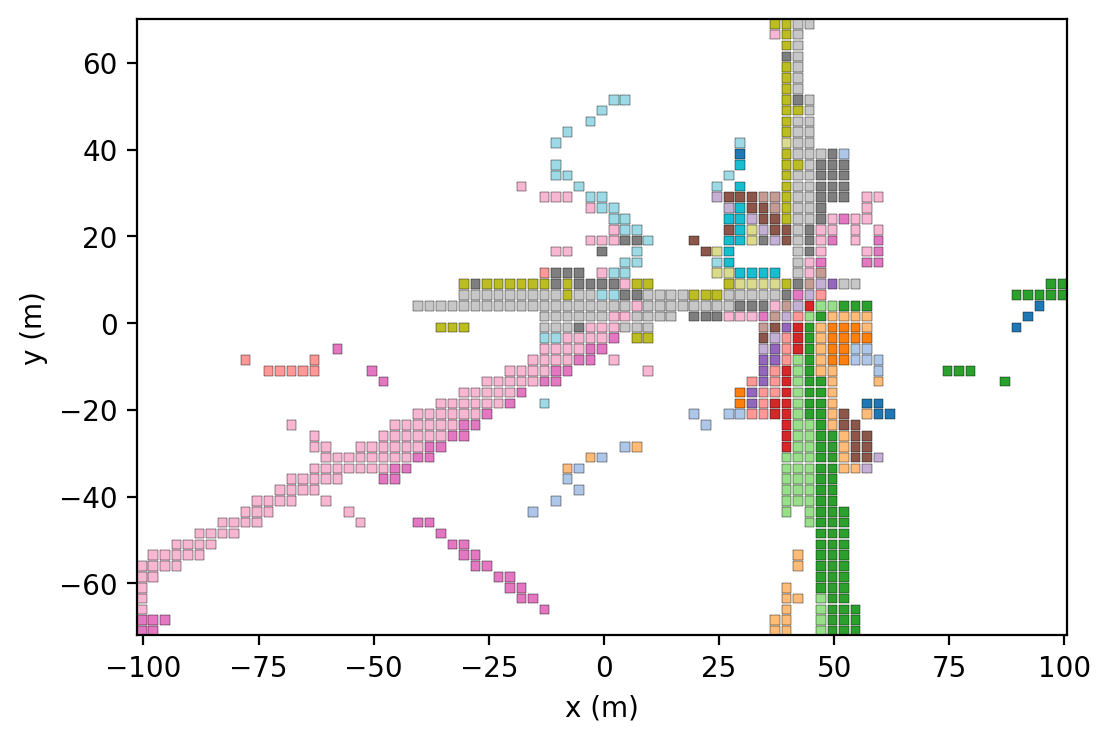


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 4480/4480 [00:00<00:00, 683787.55it/s]


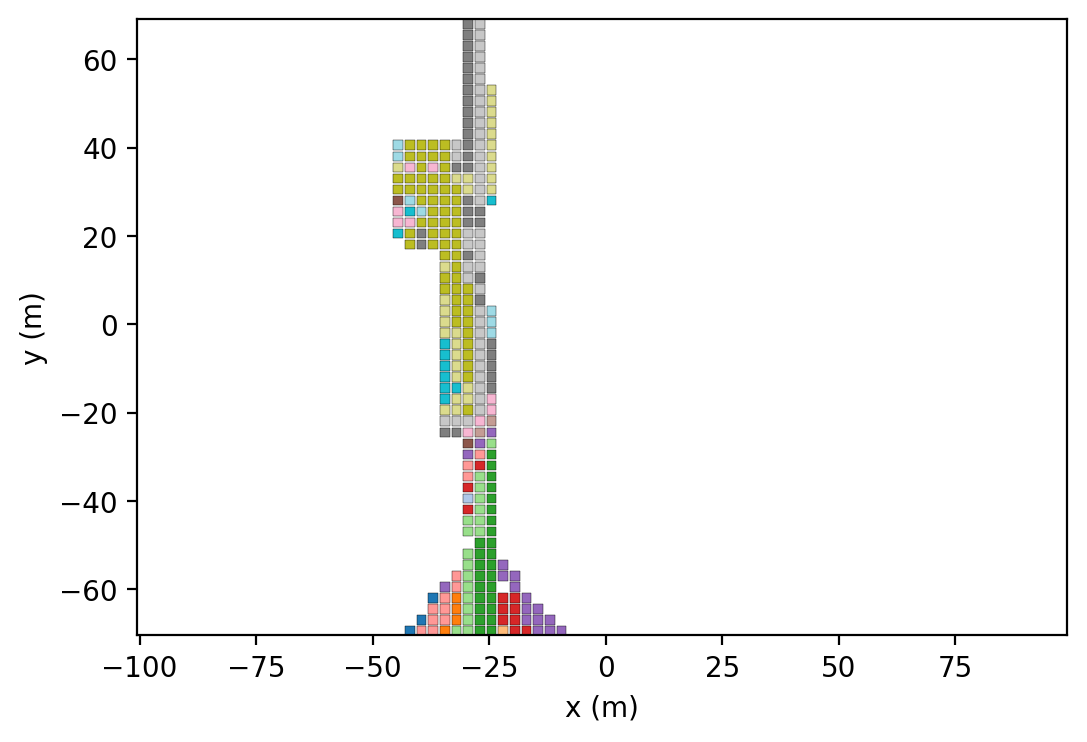


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5022/5022 [00:00<00:00, 116707.27it/s]


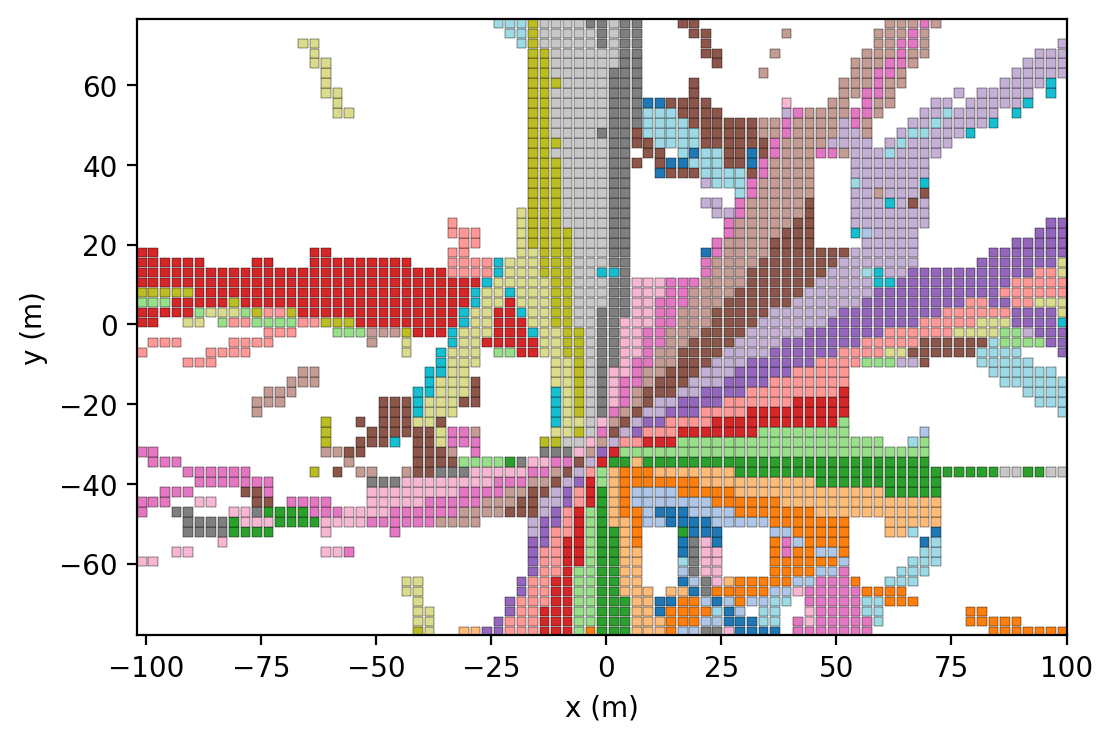


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6794/6794 [00:00<00:00, 150830.48it/s]


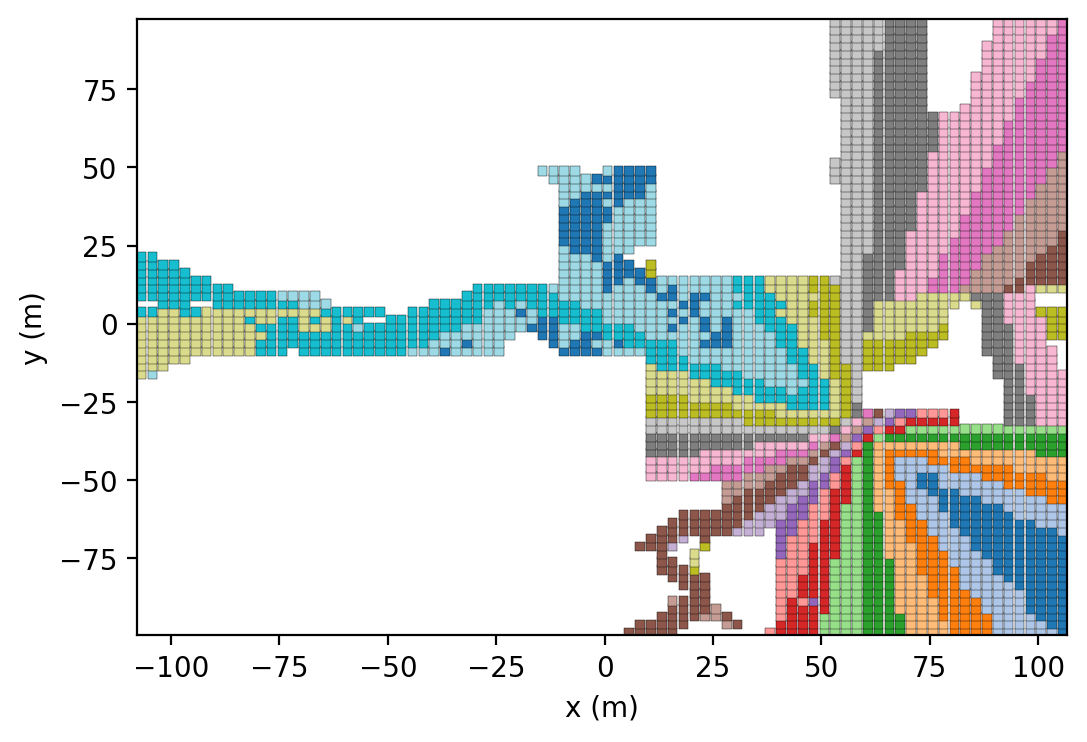


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6336/6336 [00:00<00:00, 499457.04it/s]


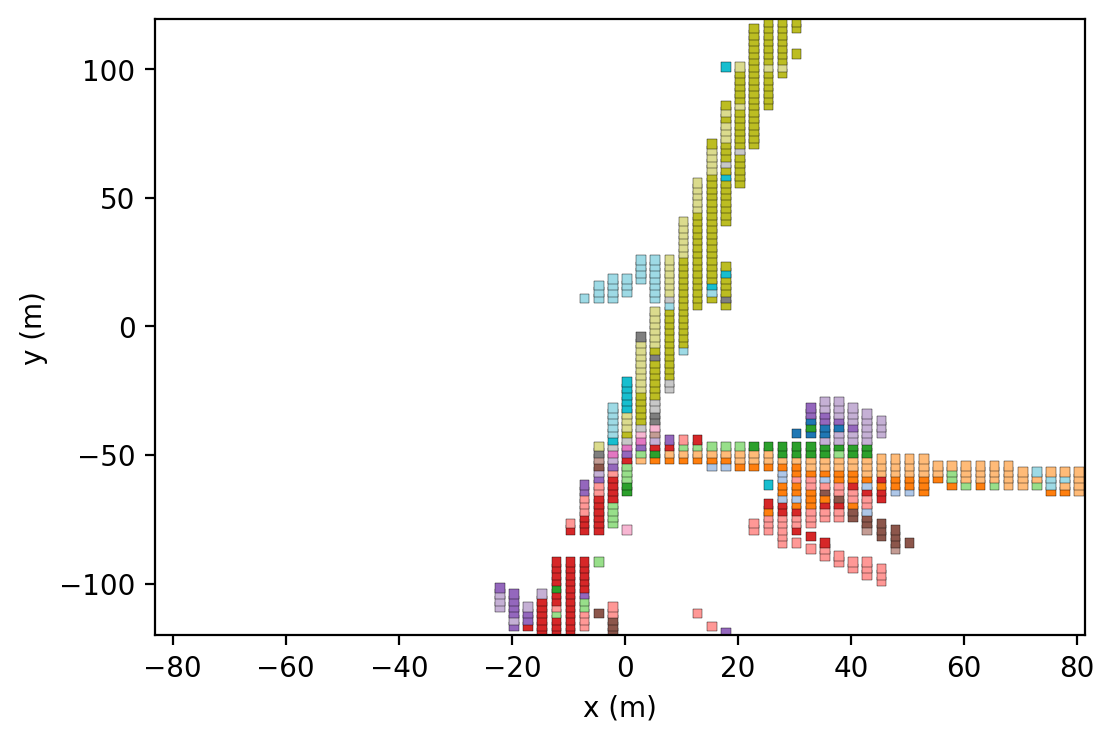


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6960/6960 [00:00<00:00, 228522.32it/s]


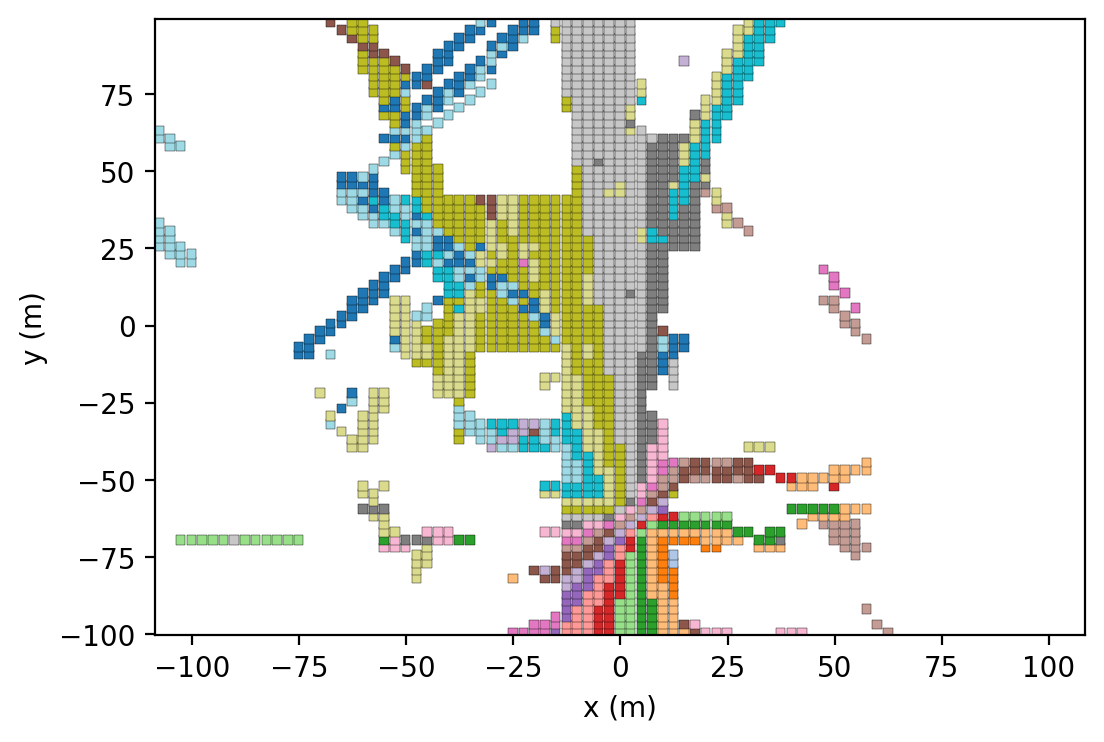


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5893/5893 [00:00<00:00, 156295.46it/s]


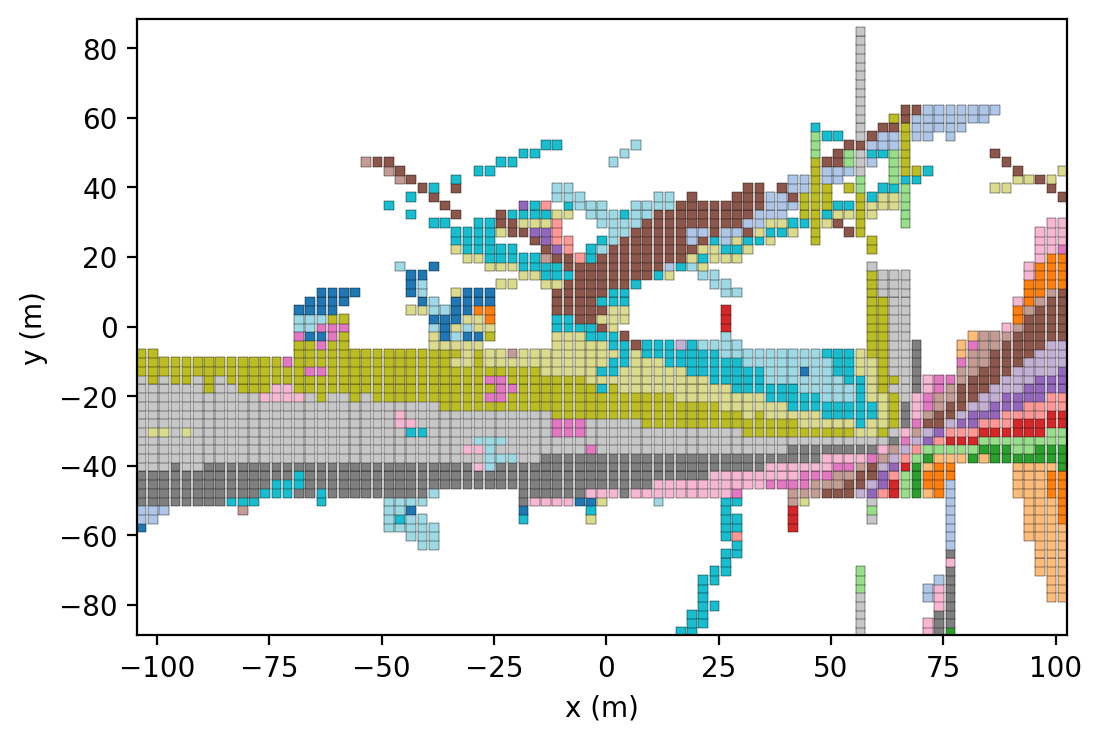


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6308/6308 [00:00<00:00, 147267.68it/s]


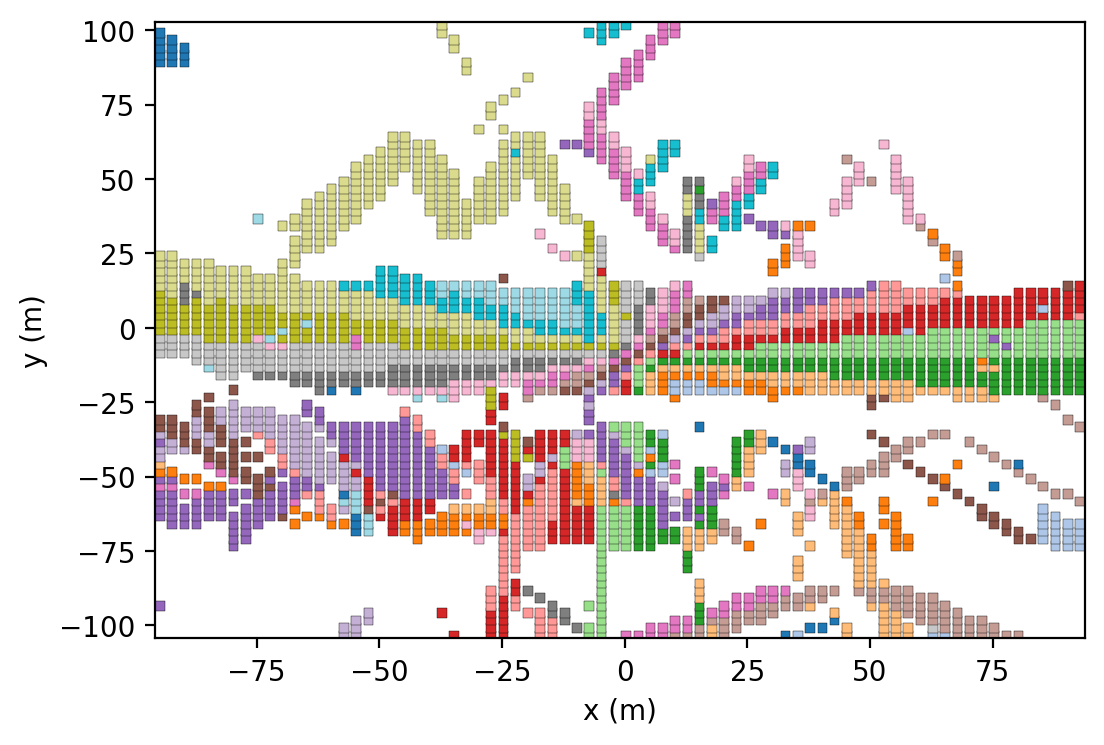


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6557/6557 [00:00<00:00, 226428.88it/s]


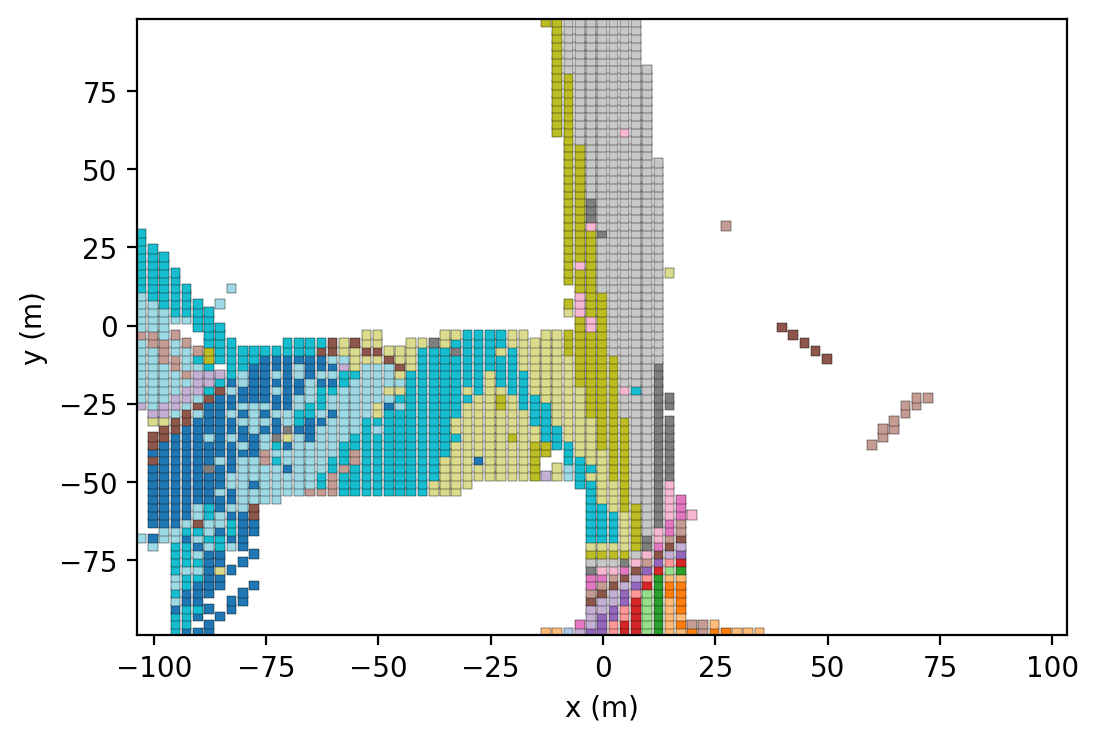


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5610/5610 [00:00<00:00, 172764.79it/s]


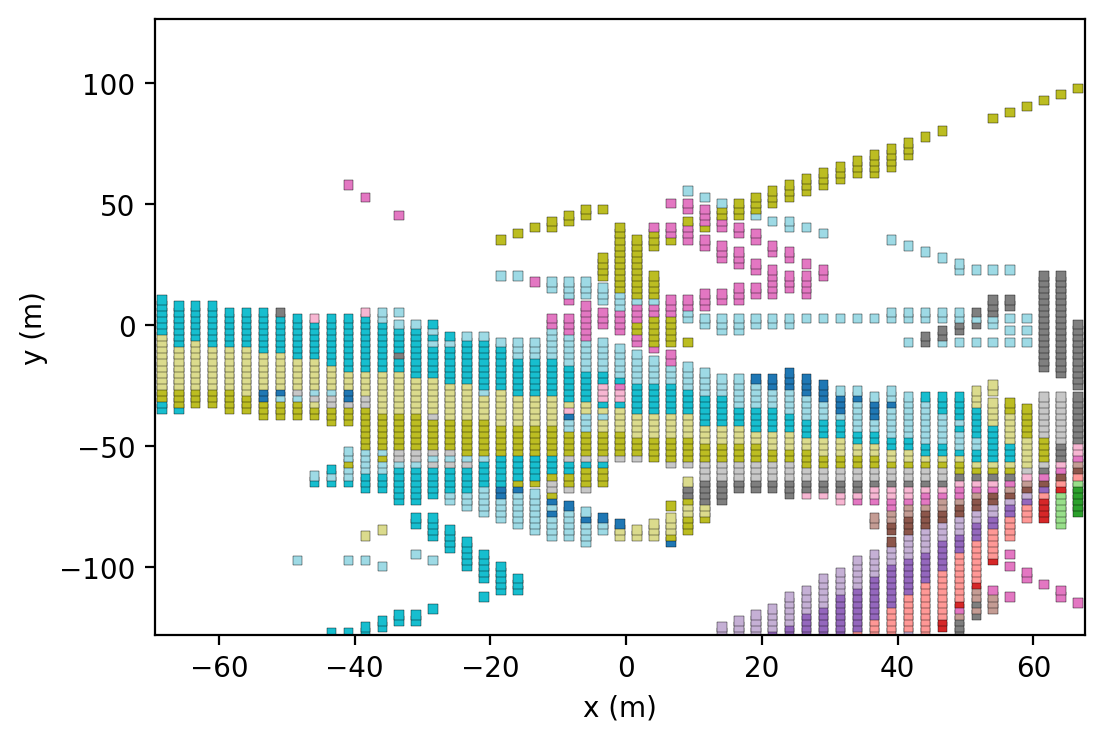


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5358/5358 [00:00<00:00, 115927.27it/s]


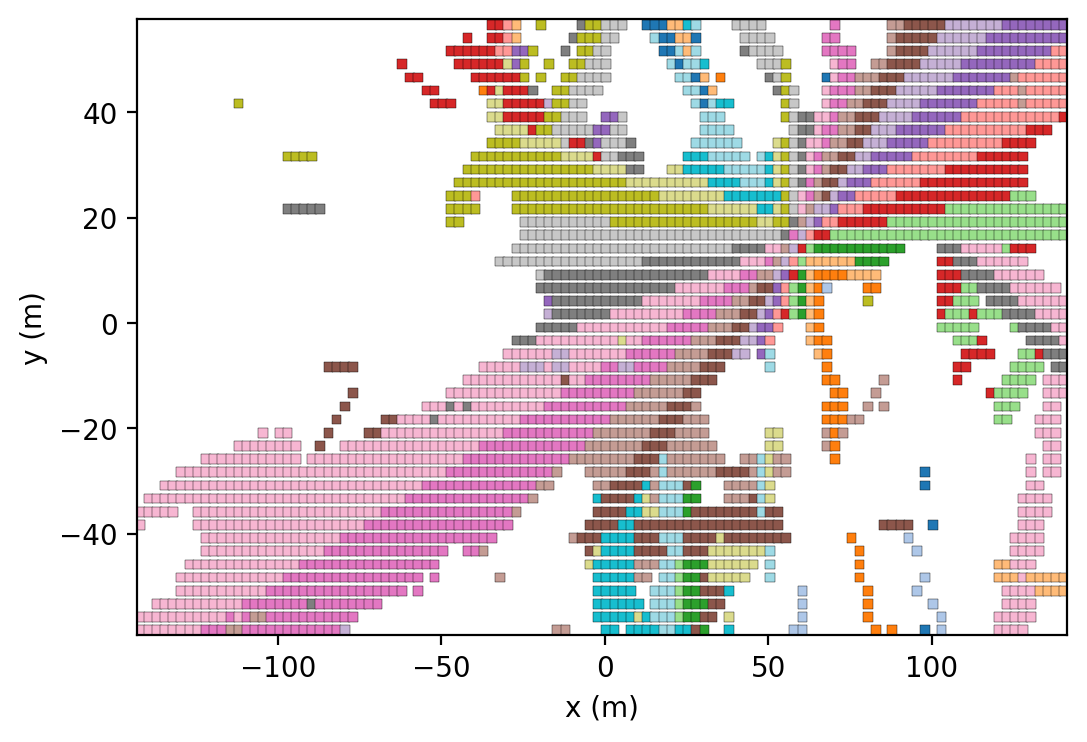


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6192/6192 [00:00<00:00, 194319.06it/s]


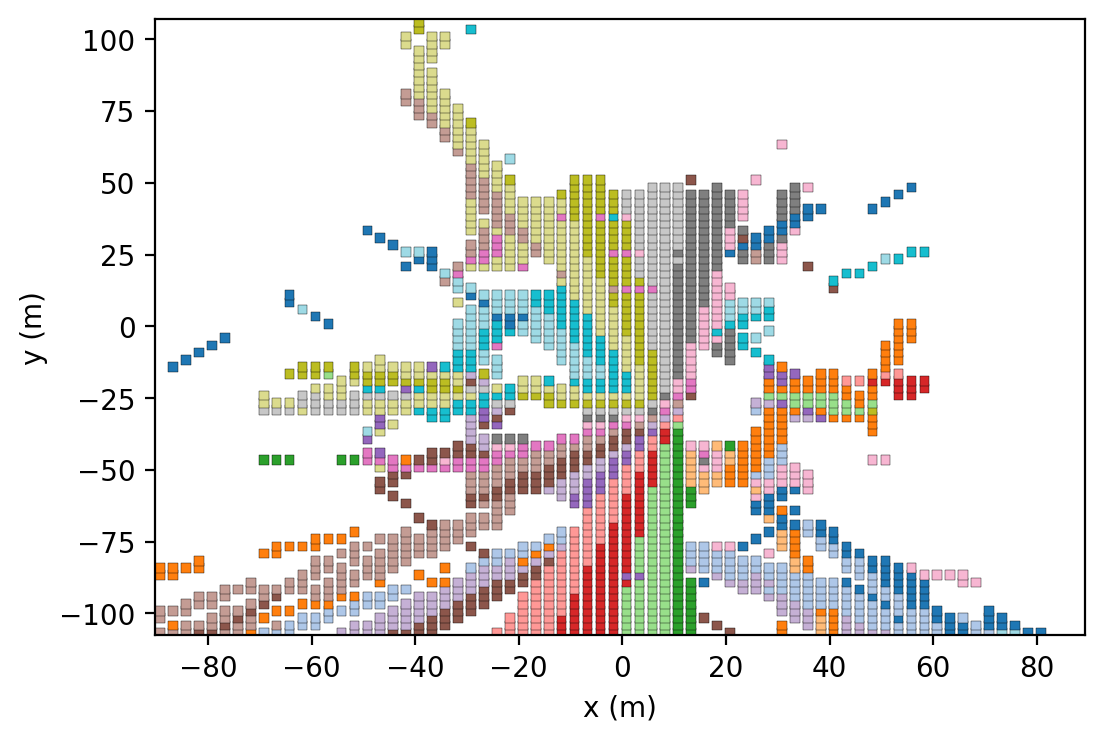


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6816/6816 [00:00<00:00, 260845.23it/s]


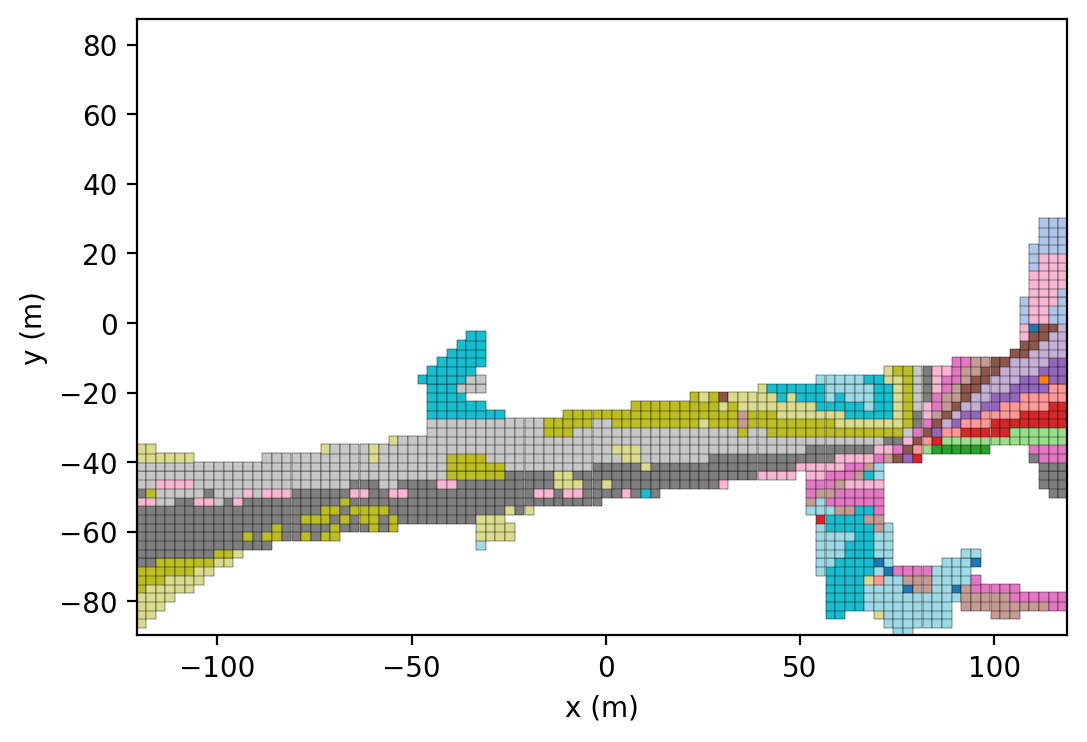


Basestation 3

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6320/6320 [00:00<00:00, 117717.07it/s]


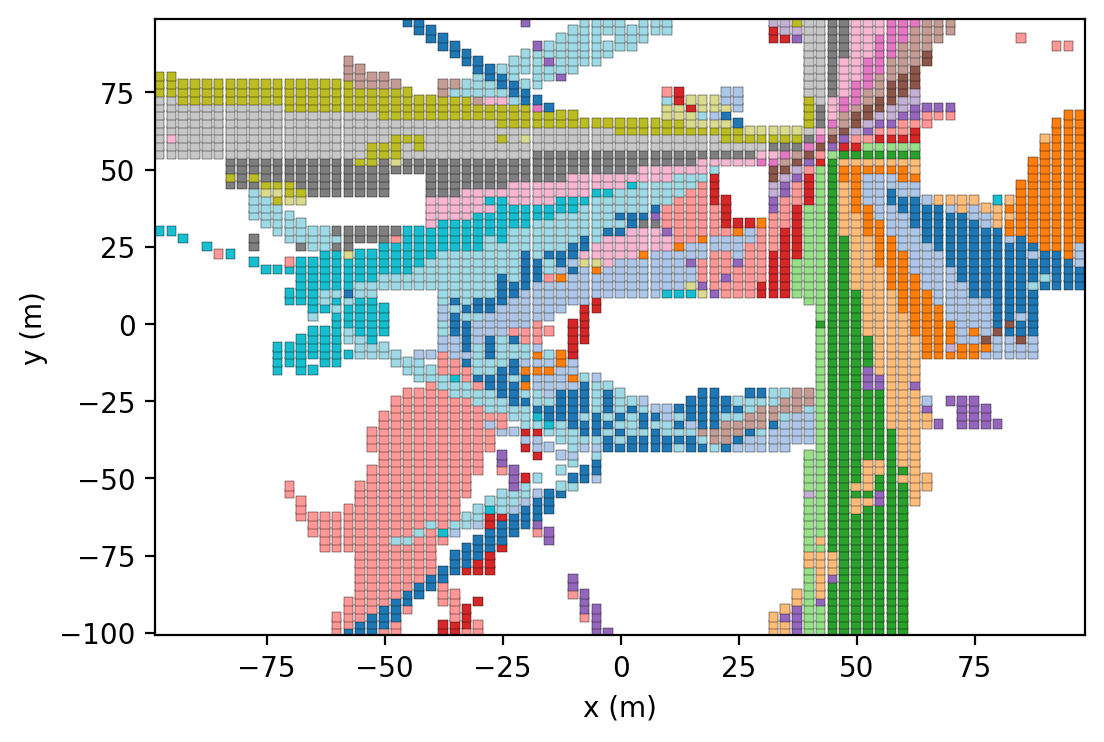


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6068/6068 [00:00<00:00, 233057.43it/s]


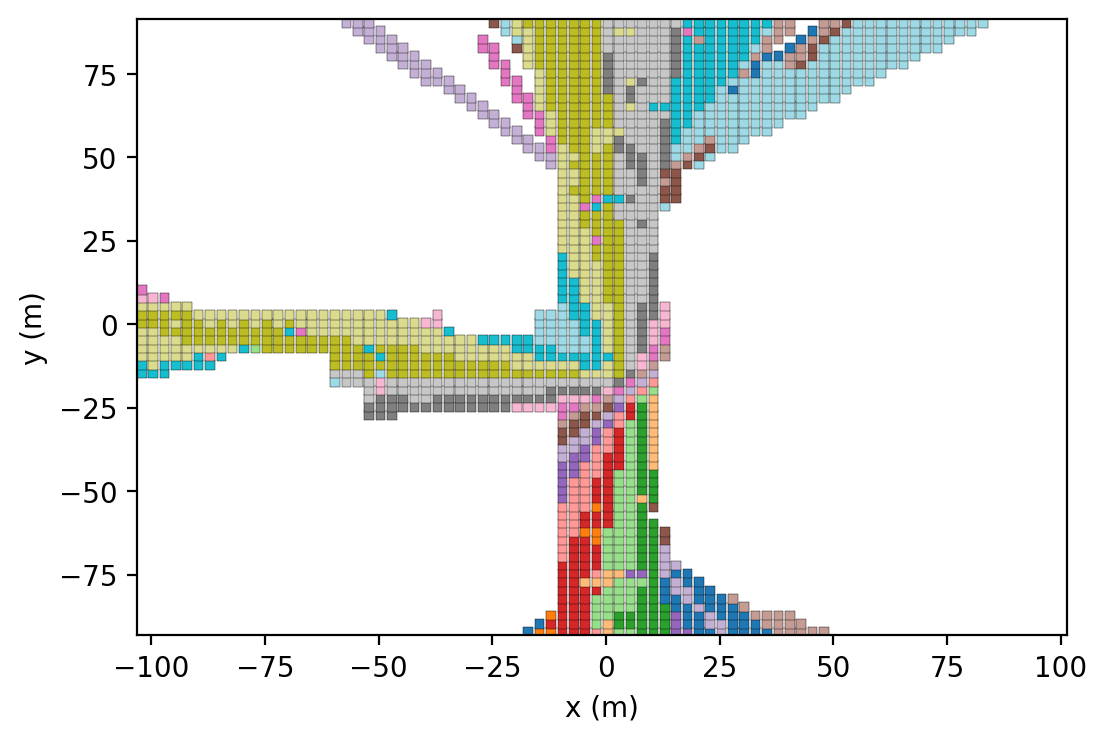


Basestation 3

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6970/6970 [00:00<00:00, 271285.79it/s]


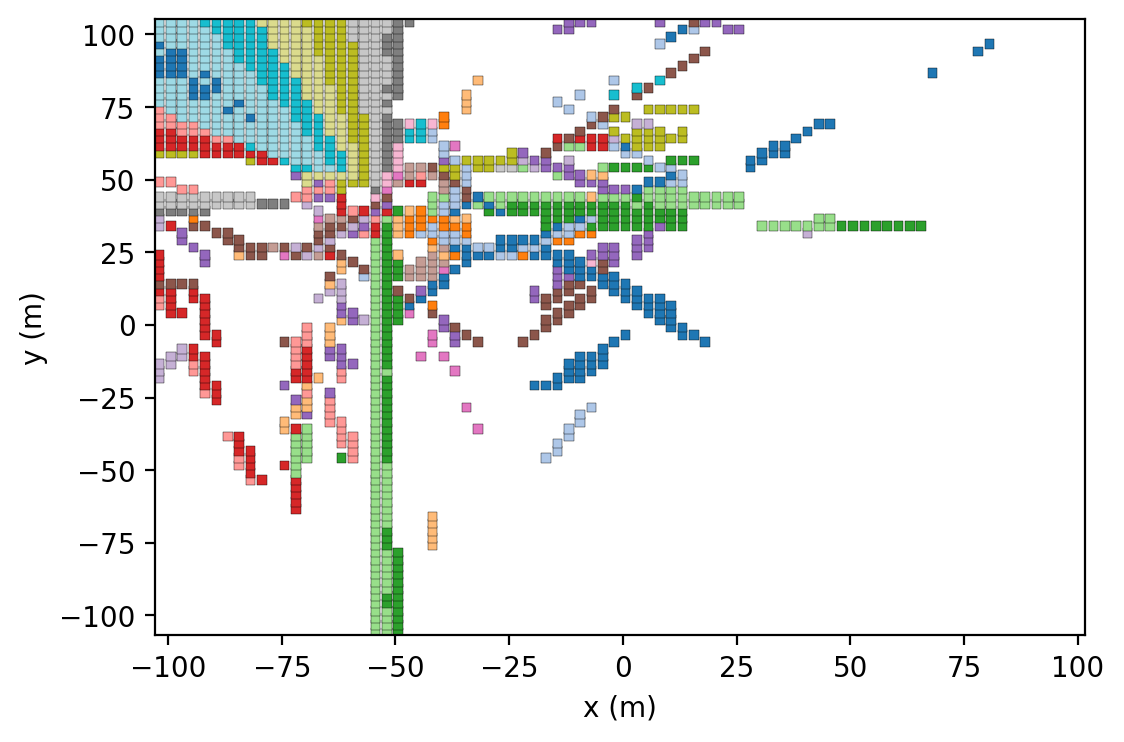


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 6150/6150 [00:00<00:00, 107955.39it/s]


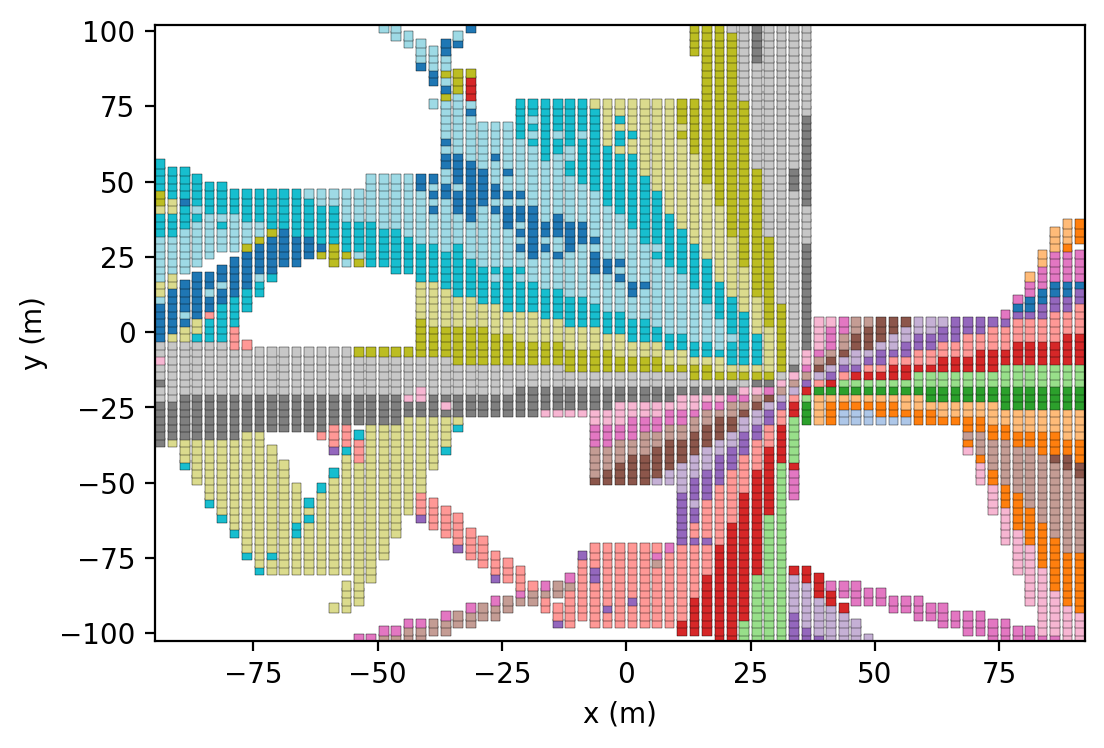

dataset:  <class 'torch.Tensor'> 33664 torch.Size([33664, 64])
labels:  <class 'torch.Tensor'> 33664


In [8]:
################Select Tasks#################################and change Beams##################
#generate targets/lables
tasks = ['LoS/NLoS Classification', 'Beam Prediction']
task = tasks[1] # Choose 0 for LoS/NLoS labels or 1 for beam prediction labels.
labels = create_labels(task, selected_scenario_names, n_beams=64)
print("dataset: ",
type(dataset),
len(dataset),
dataset.shape
)
print("labels: ",
    type(labels),len(labels)
)

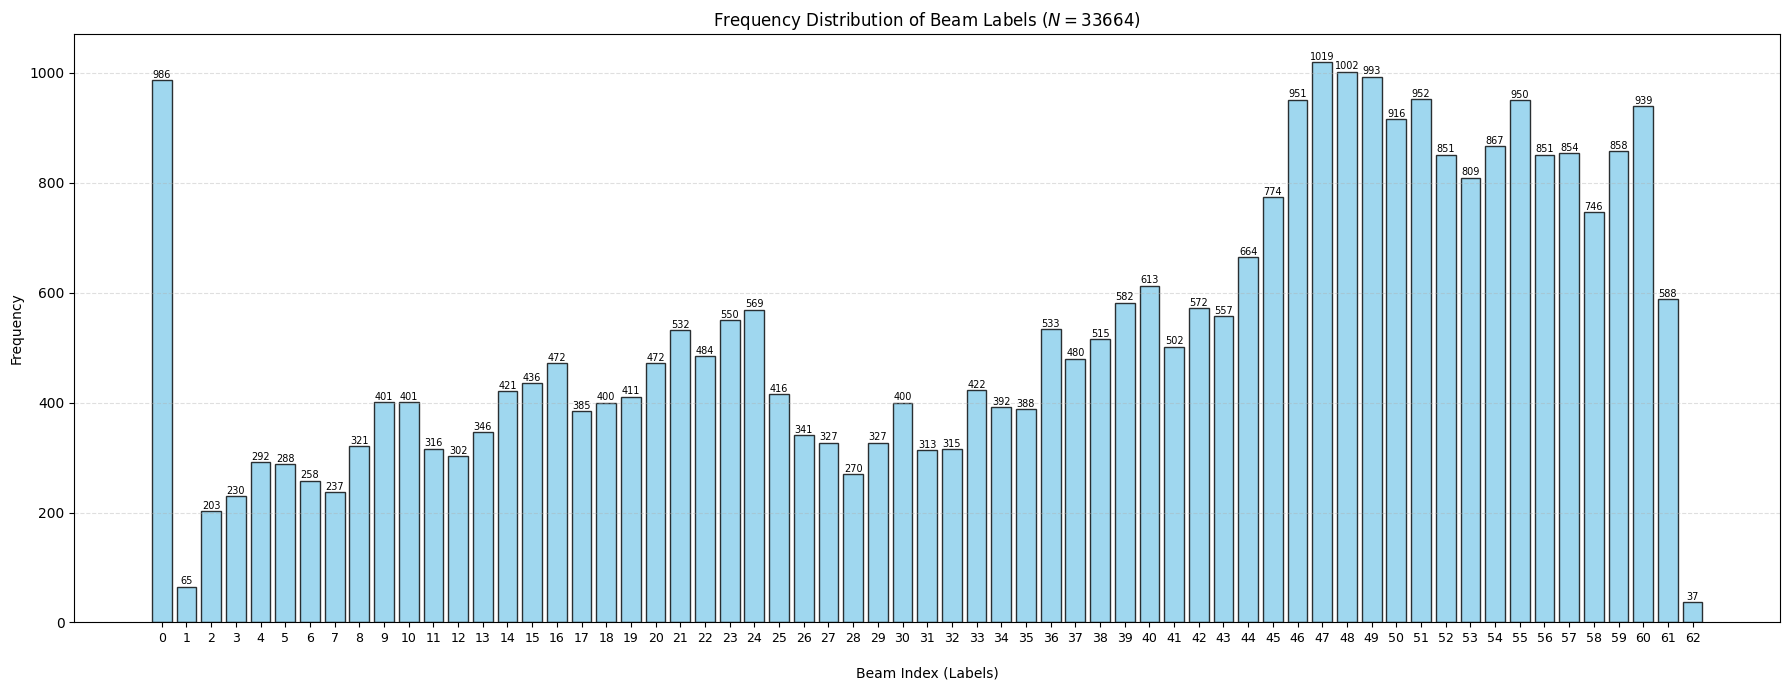

In [9]:
unique_labels, counts = torch.unique(labels, return_counts=True)
x_values = unique_labels.cpu().numpy()
y_values = counts.cpu().numpy()

# 2. Increase figure width (e.g., to 16 or 18) to create more horizontal space
plt.figure(figsize=(18, 7)) 

# 3. Create bars
bars = plt.bar(x_values, y_values, color='skyblue', edgecolor='black', alpha=0.8)

# Adding some padding with 'labelpad' if needed
plt.xticks(x_values, rotation=0, fontsize=9) 

# 5. Annotate each bar with its frequency count
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), 
             va='bottom', ha='center', fontsize=7, rotation=0)

# 6. Add labels and title
plt.xlabel('Beam Index (Labels)', labelpad=15)
plt.ylabel('Frequency')
plt.title(f'Frequency Distribution of Beam Labels ($N = {len(labels)}$)')

# 7. Use tight_layout to ensure no labels are cut off at the edges
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

In [10]:
#function to combine data and labels and split in the given train ratio ratio
def get_data_loaders(data_tensor, labels_tensor, batch_size=32, train_ratio=0.8):
    dataset = TensorDataset(data_tensor, labels_tensor)
    N = len(dataset)

    train_size = int(train_ratio * N)
    remaining = N - train_size
    val_size = remaining // 2
    test_size = remaining - val_size

    train_dataset, val_dataset, test_dataset = random_split(dataset,[train_size, val_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [11]:
# Mapping for beam prediction input types.
mapping = {
    'cls_emb': {'input_channels': 1, 'sequence_length': 64},
    'channel_emb': {'input_channels': 64, 'sequence_length': 128},
    'raw': {'input_channels': 16, 'sequence_length': 128}
}
input_type = selected_input_type  # use the same type as for data generation
params = mapping.get(input_type, mapping[selected_input_type]) #change if chosen anything else
n_beams = 64  # adjust as needed
initial_lr = 0.001
num_classes = n_beams + 1  # as defined in your code
print(selected_input_type)

cls_emb


In [19]:
# ----------------------------------
# 1. SE LAYER
# ----------------------------------
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)


# ----------------------------------
# 2. RESIDUAL BLOCK (WITH OPTIONAL SE)
# ----------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, use_se=False):
        super().__init__()

        self.conv1 = nn.Conv1d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_c)

        self.conv2 = nn.Conv1d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_c)

        self.relu = nn.ReLU(inplace=True)
        self.se = SELayer(out_c) if use_se else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm1d(out_c)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Apply SE attention (if enabled)
        out = self.se(out)

        out += identity
        out = self.relu(out)

        return out


# ----------------------------------
# 3. MAIN MODEL
# ----------------------------------
class SEResNet1D(nn.Module):
    def __init__(self, input_channels, sequence_length, num_classes):
        super().__init__()

        # No early downsampling
        self.conv1 = nn.Conv1d(
            input_channels, 64,
            kernel_size=7, stride=1, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)

        # Stage 1 (No SE)
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )

        # Stage 2 (SE starts)
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=True),
            ResidualBlock(128, 128, use_se=True)
        )

        # Stage 3 (SE)
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=True),
            ResidualBlock(256, 256, use_se=True)
        )

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.1)

        # Infer FC size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, sequence_length)
            dummy = self._forward_conv(dummy)
            flatten_size = dummy.view(1, -1).size(1)

        self.fc = nn.Linear(flatten_size, num_classes)

    def _forward_conv(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return x

    def forward(self, x):
        # Input shape: [B, L, C]
        x = x.transpose(1, 2)  # -> [B, C, L]

        x = self._forward_conv(x)
        x = x.flatten(1)
        x = self.dropout(x)

        return self.fc(x)


print("Final SE-ResNet1D Model Defined.")


# ----------------------------------
# 4. LABEL SMOOTHING LOSS
# ----------------------------------
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)

        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)

        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))


Final SE-ResNet1D Model Defined.


In [21]:
###############################change test-val-test########################################333

# Instantiate the beam prediction model.

# beam_model = res1dcnn(params['input_channels'], params['sequence_length'], num_classes).to(device)
beam_model = SEResNet1D(params['input_channels'], params['sequence_length'], num_classes).to(device)

optimizer = Adam(beam_model.parameters(), lr=initial_lr, weight_decay=1e-4)

# scheduler = MultiStepLR(optimizer, milestones=[15, 35], gamma=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, 
    T_0=10,      # Restart every 10 epochs
    T_mult=2,    # Double the restart interval (10, 20, 40...)
    eta_min=1e-6 # Minimum LR
)

print("Advanced Optimizer and Scheduler Initialized.")


num_epochs = 30

# Create DataLoaders (assuming `dataset` is a torch Dataset with (data, target) pairs).
batch_size = 32  # adjust as needed

train_loader, val_loader, test_loader = get_data_loaders(dataset, labels, train_ratio=0.2)
print("train: ",len(train_loader),'\n','validate: ',len(val_loader),'\n','test: ', len(test_loader))

# Function to plot training metrics.
def plot_training_metrics(epochs, train_losses, val_losses, val_f1_scores, save_path=None):
    plt.figure(figsize=(12, 5))
    # Loss plot.
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    # F1 score plot.
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_f1_scores, label='Validation Weighted F1', marker='o', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Weighted F1 Score')
    plt.title('F1 Score Curve')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

Advanced Optimizer and Scheduler Initialized.
train:  211 
 validate:  421 
 test:  421


In [22]:
# Training loop with weighted F1 computation.

# criterion = nn.CrossEntropyLoss()
criterion = LabelSmoothingLoss(classes=64, smoothing=0.1)

train_losses = []
val_losses = []
val_f1_scores = []
epochs_list = []

for epoch in range(1, num_epochs + 1):
    beam_model.train()
    running_loss = 0.0
    # Training with tqdm progress bar.
    for data, target in tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False):
        data, target = data.to(device), target.to(device)
        # Adjust input shape based on type.
        if input_type == 'raw':
            data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
        elif input_type == 'cls_emb':
            data = data.unsqueeze(2)
        optimizer.zero_grad()
        outputs = beam_model(data)
        loss = criterion(outputs, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(beam_model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    scheduler.step()
    train_loss = running_loss / len(train_loader.dataset)
    
    # Validation loop with tqdm.
    beam_model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_targets = []
    for data, target in tqdm(val_loader, desc=f"Epoch {epoch} Validation", leave=False):
        data, target = data.to(device), target.to(device)
        if input_type == 'raw':
            data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
        elif input_type == 'cls_emb':
            data = data.unsqueeze(2)
        outputs = beam_model(data)
        loss = criterion(outputs, target)
        val_running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
    val_loss = val_running_loss / len(val_loader.dataset)
    val_f1 = f1_score(all_targets, all_preds, average='weighted')
    
    epochs_list.append(epoch)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    
    print(f"Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Weighted F1: {val_f1:.4f}")

Epoch 1/30: Train Loss: 3.4074 | Val Loss: 2.9843 | Val Weighted F1: 0.0956


Epoch 2/30: Train Loss: 2.9551 | Val Loss: 2.8816 | Val Weighted F1: 0.1091


Epoch 3/30: Train Loss: 2.8019 | Val Loss: 2.7204 | Val Weighted F1: 0.1520


Epoch 4/30: Train Loss: 2.7179 | Val Loss: 2.6394 | Val Weighted F1: 0.1748


Epoch 5/30: Train Loss: 2.5867 | Val Loss: 2.5461 | Val Weighted F1: 0.2120


...

Epoch 26/30: Train Loss: 1.7163 | Val Loss: 2.1354 | Val Weighted F1: 0.4385


Epoch 27/30: Train Loss: 1.6605 | Val Loss: 2.1149 | Val Weighted F1: 0.4488


Epoch 28/30: Train Loss: 1.6158 | Val Loss: 2.0895 | Val Weighted F1: 0.4609


Epoch 29/30: Train Loss: 1.5935 | Val Loss: 2.0844 | Val Weighted F1: 0.4623


Epoch 30/30: Train Loss: 1.5694 | Val Loss: 2.0852 | Val Weighted F1: 0.4654


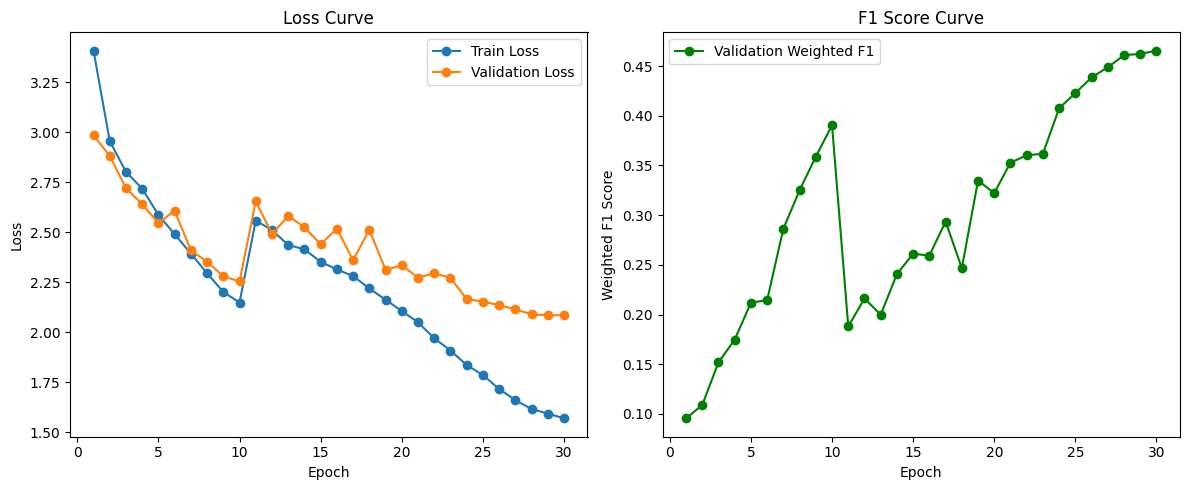

Testing: 100%|██████████| 421/421 [00:02<00:00, 209.83it/s]

Test Loss: 2.0792, Test Accuracy: 46.98%, F1 Score: 0.4654
211 421 421
cls_emb


In [23]:
# Plot training metrics.
plot_training_metrics(epochs_list, train_losses, val_losses, val_f1_scores)

# Test evaluation with tqdm.
beam_model.eval()
test_running_loss = 0.0
correct = 0
total = 0
for data, target in tqdm(test_loader, desc="Testing"):
    data, target = data.to(device), target.to(device)
    if input_type == 'raw':
        data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
    elif input_type == 'cls_emb':
        data = data.unsqueeze(2)
    outputs = beam_model(data)
    loss = criterion(outputs, target)
    test_running_loss += loss.item() * data.size(0)
    _, predicted = torch.max(outputs, 1)
    total += target.size(0)
    correct += (predicted == target).sum().item()
test_loss = test_running_loss / len(test_loader.dataset)
accuracy = 100 * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%, F1 Score: {val_f1:.4f}")
print(len(train_loader),len(test_loader),len(val_loader))
print(selected_input_type)